T1 = 22.77 degC   T2 = 18.52 degC
Binarios escritos en: /Volumes/ESTEBAN_MIT/MITgcm/verification/BayIW_Rectan_2layer/input/profiles_2layer


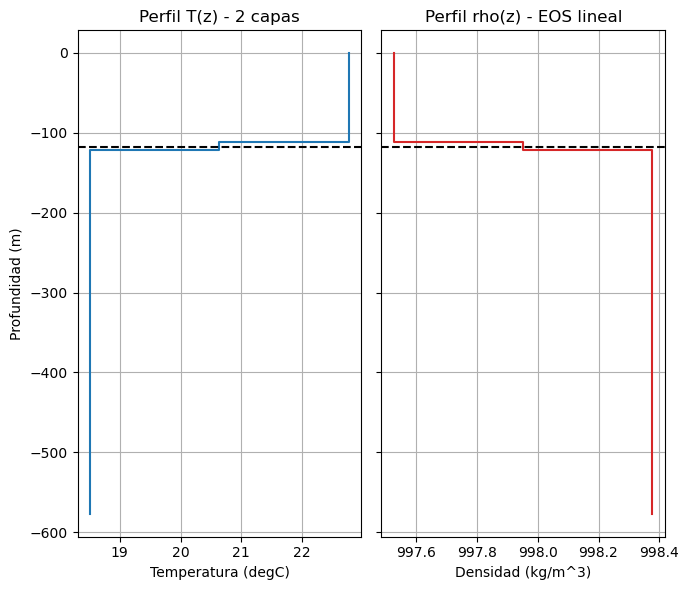

In [1]:
"""
Genera binarios MITgcm (T y S) para un perfil de DOS CAPAS
  - Capa 1: rho1 = 997.527 kg/m^3   (T1 calculada)
  - Capa 2: rho2 = 998.377 kg/m^3   (T2 calculada)
  - Interface a z* = 117.52499 m (profundidades positivas hacia abajo)
Usa EOS LINEAR del MITgcm con sBeta=0 (densidad depende solo de T).
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONSTANTES DEL MODELO (tomadas de data) ----------------------------
RHO0  = 999.8       # kg m-3   (rhoNil)
ALPHA = 2.0e-4      # 1/degC   (tAlpha)
SBETA = 0.0         #          (sBeta)
TREF  = 11.4        # degC     (tRef constante en data)
SREF  = 0.0         # psu      (sRef constante en data)

# --- 1. Funciones auxiliares --------------------------------------------
def rho_linear(T, S=SREF):
    """EOS lineal MITgcm (densidad absoluta)."""
    return RHO0 * (1.0 + SBETA * (S - SREF) - ALPHA * (T - TREF))

def rho_to_temp(rho_abs, S=SREF):
    """Convierte densidad deseada a temperatura usando EOS lineal."""
    return TREF + (1.0 + SBETA * (S - SREF) - rho_abs / RHO0) / ALPHA

def write_binary_3d(field_1d, nx, ny, fname):
    """Replica un vector (nz,) -> (nz,ny,nx) y lo escribe big-endian float64."""
    np.tile(field_1d[:, None, None], (1, ny, nx)).astype('>f8').tofile(fname)

# --- 2. Geometria vertical (delR -> RC) ----------------------------------
delR = np.array([
    1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.9,
    2.0,2.2,2.4,2.6,2.8,3.0,3.2,3.5,
    3.8,4.1,4.4,4.8,5.2,5.6,6.0,6.5,
    7.1,7.6,8.2,8.9,9.6,10.4,11.3,12.2,
    13.2,14.3,15.4,16.7,18.0,19.5,21.1,22.8,
    24.6,26.6,28.8,31.1,33.7,36.4,39.3,42.5,
    45.8])
R_faces = np.r_[0, delR.cumsum()]
RC = 0.5 * (R_faces[:-1] + R_faces[1:])

# --- 3. Parametros de la capa -------------------------------------------
rho1, rho2 = 997.527, 998.377
z_interface = 117.52499

T1, T2 = rho_to_temp(rho1), rho_to_temp(rho2)
print(f"T1 = {T1:.2f} degC   T2 = {T2:.2f} degC")

# --- 4. Construir perfil T(z) de dos capas ------------------------------
T = np.where(RC < z_interface, T1, T2)
S = np.zeros_like(T)

rho_profile = rho_linear(T, S)

# --- 5. Guardar binarios ------------------------------------------------
nx, ny, nz = 560, 352, len(RC)
outdir = Path("profiles_2layer")
outdir.mkdir(exist_ok=True)

write_binary_3d(T, nx, ny, outdir / f"T_2layer_{nz}z_{nx}x{ny}.bin")
write_binary_3d(S, nx, ny, outdir / f"S_dummy_{nz}z_{nx}x{ny}.bin")

print("Binarios escritos en:", outdir.resolve())

# --- 6. Visualizacion ---------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7,6), sharey=True)
ax1.step(T, -RC, where='mid')
ax1.axhline(-z_interface, color='k', ls='--')
ax1.set_xlabel('Temperatura (degC)')
ax1.set_ylabel('Profundidad (m)')
ax1.set_title('Perfil T(z) - 2 capas')
ax1.grid()

ax2.step(rho_profile, -RC, where='mid', color='tab:red')
ax2.axhline(-z_interface, color='k', ls='--')
ax2.set_xlabel('Densidad (kg/m^3)')
ax2.set_title('Perfil rho(z) - EOS lineal')
ax2.grid()

plt.tight_layout()
plt.show()


In [2]:
for Tii, ii in zip(np.round(T, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 
22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 
22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 22.8, 
22.8, 22.8, 22.8, 22.8, 22.8, 18.5, 18.5, 18.5, 
18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 
18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 18.5, 
18.5, 

In [4]:
#tRef = 11.4 vector de temperatura constante en data
tRef= np.zeros_like(T) + 11.4

for Tii, ii in zip(np.round(tRef, decimals=1), range(len(RC))):
    print(f'{Tii},', end=" ")
    if ii!=0 and ii%8 == 0:
        print('')

11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 11.4, 
11.4, 

In [3]:
T_array = np.expand_dims(np.expand_dims(T, axis=1), axis=1)
T_array = T_array * np.ones((nz,ny,nx))

S_array = np.expand_dims(np.expand_dims(S, axis=1), axis=1)
S_array = S_array * np.ones((nz,ny,nx))
dt = np.dtype('>f8')  # float 64 big endian

# Save binary file
filename = "2layer_temp_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
T_array.astype(dt).tofile(fileobj,"")
fileobj.close()

filename = "2layer_salt_%dzlev_%dx%d.bin" %(nz,nx,ny)
fileobj = open(filename,mode='wb')
S_array.astype(dt).tofile(fileobj,"")
fileobj.close()